# ORTEC Dynamic Pricing Case

We estimate price elasticity from observational booking data and turn it into per-ROMGID price recommendations. The core challenge is causal: the historical pricer reacts to demand, so naive regression sees prices and bookings rise together and concludes (wrongly) that higher prices cause more bookings. We address this by conditioning on **bookings-on-books**, the demand signal the pricer itself responds to, which closes the demand → price backdoor.

**Pipeline:**
1. Load + sanity check the synthetic dataset
2. EDA — booking patterns, ROMGID structure
3. Feature engineering (incl. bookings-on-books)
4. DAG-identified Bayesian hierarchical Negative-Binomial model
5. Optimizer — translate the elasticity into revenue-maximizing prices
6. Export to decision dashboard

In [ ]:
# === Setup ===
# Set PyTensor cxx to empty BEFORE importing pymc/bambi to silence the
# 'g++ not available' warning. We use the numpyro backend below, which
# doesn't need a C++ compiler — JAX handles the gradients.
import os
os.environ['PYTENSOR_FLAGS'] = 'cxx='

import time
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import bambi as bmb
import arviz as az

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


## 1. Load data

In [3]:
df = pd.read_csv('simulation_output.csv')

C:\Users\tobia\AppData\Local\Temp\ipykernel_17460\3217010146.py:1: DtypeWarning: Columns (0: DeckingType, 1: Kitchen, 2: DeckingExtras) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('simulation_output.csv')


In [4]:
df.head(20)

,ReservableOptionMarketGroupId,WeekBeforeArrival,WeekStartDate,MarketGroupCode,BrandGroupCode,CampsiteCode,AccoKindCode,AccoTypeRangeCode,SpecialPeriodCode,SeasonalCluster,...,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
0,Domestic-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,1,0,20,234,0,35.2708,22.4478,12.0
1,DACH-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0
2,Benelux-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,32,234,0,35.2708,22.4478,12.0
3,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,52,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
4,Domestic-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0
5,DACH-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,3,0,63,234,0,35.2708,22.4478,12.0
6,Benelux-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,1,0,32,234,0,35.2708,22.4478,12.0
7,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,51,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
8,Domestic-Thundurus-Meditite-Mobile-2024-01-01,50,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0
9,DACH-Thundurus-Meditite-Mobile-2024-01-01,50,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0


In [5]:
df.describe()

,WeekBeforeArrival,Airco,Bedrooms,HotTub,Tropical,Bathrooms,Sleeps,TV,ArrivalMonth,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
count,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3130816.0,3.130816e+06,3130816.0,3.130816e+06,3.130816e+06,3130816.0,3.130816e+06,3.130816e+06,3.130816e+06
mean,2.600000e+01,3.098592e-01,2.007042e+00,1.126761e-01,2.183099e-01,1.415493e+00,3.413310e+02,4.929577e-01,6.490385e+00,2.126906e+02,0.0,9.321742e-01,0.0,4.940523e+01,3.465669e+02,0.0,4.833767e+01,7.217771e+00,1.253713e+01
std,1.529706e+01,4.624354e-01,1.010484e+00,3.161964e-01,4.130989e-01,6.307046e-01,1.549068e+02,4.999505e-01,3.447394e+00,1.323063e+02,0.0,2.338494e+00,0.0,5.668432e+01,1.591119e+02,0.0,8.719626e+00,1.029888e+01,7.502503e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.050000e+02,0.000000e+00,1.000000e+00,4.206000e+01,0.0,0.000000e+00,0.0,0.000000e+00,1.050000e+02,0.0,3.344880e+01,-6.975400e+00,-3.500000e+00
25%,1.300000e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.210000e+02,0.000000e+00,3.750000e+00,1.071175e+02,0.0,0.000000e+00,0.0,8.000000e+00,2.280000e+02,0.0,4.073920e+01,-2.146300e+00,6.800000e+00
50%,2.600000e+01,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.205000e+02,0.000000e+00,6.500000e+00,1.843400e+02,0.0,0.000000e+00,0.0,3.100000e+01,3.240000e+02,0.0,4.809790e+01,5.509600e+00,1.250000e+01
75%,3.900000e+01,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,4.290000e+02,1.000000e+00,9.000000e+00,2.737900e+02,0.0,1.000000e+00,0.0,7.100000e+01,4.350000e+02,0.0,5.748670e+01,1.756240e+01,1.750000e+01
max,5.200000e+01,1.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,9.500000e+02,1.000000e+00,1.200000e+01,6.650600e+02,0.0,1.330000e+02,0.0,5.650000e+02,9.500000e+02,0.0,6.232910e+01,2.619230e+01,2.800000e+01


## 2. EDA

Three checks: (a) data integrity — does `TotalBookedNights` line up with the cumulative `HistoricalBookedNights`? (b) categorical structure — what's the cardinality at each grouping level? (c) booking dynamics — what does the WeekBeforeArrival pattern actually look like for a few ROMGIDs?

In [6]:
#Data integrity
identity = (df.groupby(["ReservableOptionMarketGroupId", "WeekStartDate"], observed=True)
              .agg(HBN_sum=("HistoricalBookedNights", "sum"),
                   TBN_first=("TotalBookedNights", "first"),
                   TBN_nunique=("TotalBookedNights", "nunique")))
identity["diff"] = identity["HBN_sum"] - identity["TBN_first"]
print(f"ROMGIDs with constant TBN across snapshots:  {(identity['TBN_nunique'] == 1).all()}")
print(f"TBN == sum(HBN) holds for all ROMGIDs:       {(identity['diff'] == 0).all()}")
print(f"Total ROMGIDs checked: {len(identity):,}")

# === 2. LastYear columns: confirm all-zero → drop ===
ly_cols = ["DiscountedPriceLastYear", "HistoricalBookedNightsLastYear", "CapacityLastYear"]
print("\nLastYear columns — max value (expect 0):")
print(df[ly_cols].max())

# === 3. Redundancy: AccoKind vs AccommodationType, AccoTypeRange vs AccommodationRange ===
print("\nAccoKindCode × AccommodationType (1:1 means drop one):")
print(pd.crosstab(df["AccoKindCode"], df["AccommodationType"]))
print("\nAccoTypeRangeCode × AccommodationRange:")
print(pd.crosstab(df["AccoTypeRangeCode"], df["AccommodationRange"]))


ROMGIDs with constant TBN across snapshots:  True
TBN == sum(HBN) holds for all ROMGIDs:       True
Total ROMGIDs checked: 59,072

LastYear columns — max value (expect 0):
DiscountedPriceLastYear           0.0
HistoricalBookedNightsLastYear    0.0
CapacityLastYear                  0.0
dtype: float64

AccoKindCode × AccommodationType (1:1 means drop one):
AccommodationType  All-Inclusive   Basic  Self-Catering  Serviced
AccoKindCode                                                     
Mobile                    308672  220480         198432    132288
Permanent                 110240  220480         154336    330720
Seasonal                  132288  220480         154336    154336
Static                    176384  220480         220480    176384

AccoTypeRangeCode × AccommodationRange:
AccommodationRange  Budget     Mid  Premium
AccoTypeRangeCode                          
Comfort             242528  286624   132288
Family              176384  220480   110240
Luxury              330720  30

In [7]:
cat_cols = ["MarketGroupCode", "BrandGroupCode", "CampsiteCode", "AccoKindCode",
            "AccoTypeRangeCode", "SpecialPeriodCode", "SeasonalCluster", "CampsiteCluster",
            "CampsiteCountry", "CampsiteRegion", "CampsiteType",
            "AccommodationType", "AccommodationRange",
            "DeckingType", "Roof", "Kitchen", "DeckingExtras"]

print("Unique values per categorical column:")
print(df[cat_cols].nunique().sort_values())

print("\nSpecialPeriodCode value counts:")
print(df["SpecialPeriodCode"].value_counts(dropna=False))

print("\nMissingness % per column (non-zero only):")
miss = df.isna().mean().sort_values(ascending=False)
print((miss[miss > 0] * 100).round(2))


Unique values per categorical column:
AccommodationRange      3
MarketGroupCode         4
AccommodationType       4
AccoKindCode            4
Kitchen                 4
DeckingType             4
AccoTypeRangeCode       5
Roof                    5
DeckingExtras           5
CampsiteType            8
CampsiteCountry         8
SpecialPeriodCode       9
CampsiteRegion         10
CampsiteCluster       142
BrandGroupCode        142
SeasonalCluster       142
CampsiteCode          142
dtype: int64

SpecialPeriodCode value counts:
SpecialPeriodCode
Sunny Castform Season    722496
Glaceon's Rest           602080
Standard Week            421456
Shaymin Bloom            421456
Togepi Celebration       240832
Haunter's Eve            240832
Festival of Arceus       180624
Delibird's Gift Week     180624
Harvest Trevenant        120416
Name: count, dtype: int64

Missingness % per column (non-zero only):
DeckingExtras    22.54
Kitchen          21.13
DeckingType      17.61
dtype: float64


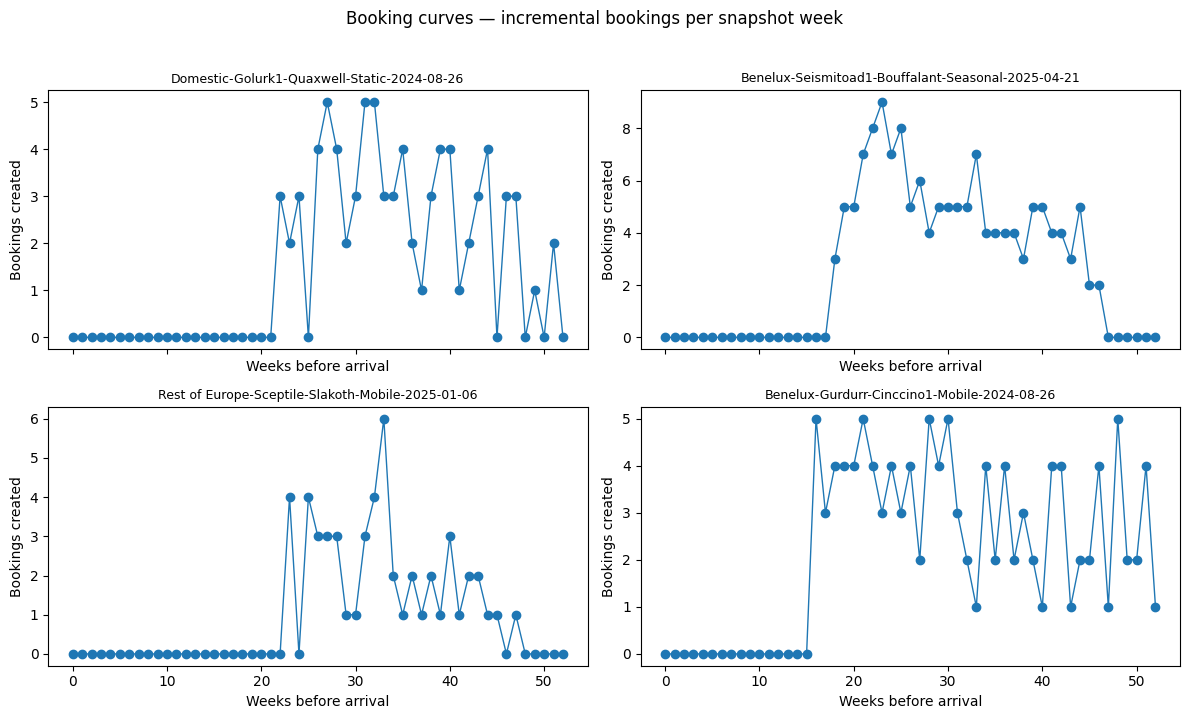

In [8]:


# Pick 4 non-empty ROMGIDs at random for variety
sample_keys = (df.groupby("ReservableOptionMarketGroupId")["TotalBookedNights"]
                 .first()
                 .pipe(lambda s: s[s > 50])
                 .sample(4, random_state=42).index)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, key in zip(axes.flat, sample_keys):
    sub = (df[df["ReservableOptionMarketGroupId"] == key]
             .sort_values("WeekBeforeArrival", ascending=False))
    ax.plot(sub["WeekBeforeArrival"], sub["HistoricalBookedNights"], marker="o", lw=1)
    ax.set_title(key, fontsize=9)
    ax.invert_xaxis()
    ax.set_xlabel("Weeks before arrival"); ax.set_ylabel("Bookings created")
fig.suptitle("Booking curves — incremental bookings per snapshot week", y=1.02)
fig.tight_layout(); plt.show()


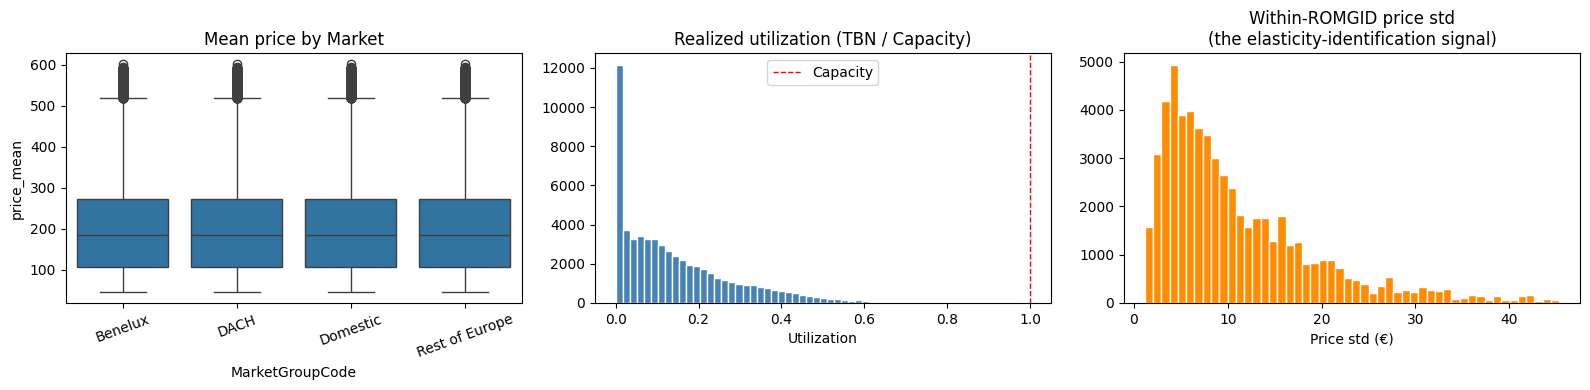

Median utilization:                        10.47%
% ROMGIDs near capacity (>=90% util):      0.00%
Median within-ROMGID price std:            €8.46
% ROMGIDs with any price variation:        100.00%


In [9]:


# ROMGID-level summary
romgid = (df.groupby(["ReservableOptionMarketGroupId", "WeekStartDate", "MarketGroupCode",
                      "AccoKindCode", "CampsiteCountry"], observed=True)
            .agg(price_mean=("DiscountedPrice", "mean"),
                 price_std=("DiscountedPrice", "std"),
                 TBN=("TotalBookedNights", "first"),
                 Cap=("Capacity", "first"))
            .reset_index())
romgid["utilization"] = romgid["TBN"] / romgid["Cap"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=romgid, x="MarketGroupCode", y="price_mean", ax=axes[0])
axes[0].set_title("Mean price by Market")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(romgid["utilization"], bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(1.0, color="red", lw=1, ls="--", label="Capacity")
axes[1].set_title("Realized utilization (TBN / Capacity)")
axes[1].set_xlabel("Utilization"); axes[1].legend()

axes[2].hist(romgid["price_std"].dropna(), bins=50, color="darkorange", edgecolor="white")
axes[2].set_title("Within-ROMGID price std\n(the elasticity-identification signal)")
axes[2].set_xlabel("Price std (€)")

fig.tight_layout(); plt.show()

print(f"Median utilization:                        {romgid['utilization'].median():.2%}")
print(f"% ROMGIDs near capacity (>=90% util):      {(romgid['utilization'] >= 0.9).mean():.2%}")
print(f"Median within-ROMGID price std:            €{romgid['price_std'].median():.2f}")
print(f"% ROMGIDs with any price variation:        {(romgid['price_std'] > 0).mean():.2%}")


## 3. Feature engineering

Drop unusable columns, derive `log_price`/`log_capacity`/`is_special`, and construct the **group key** (`campsite × accokind × accotyperange × marketgroup`) that defines the 568 partial-pooling units in the hierarchical model. Accommodation type and range are kept as fixed effects — making them random would shrink the per-group cells below the size needed to estimate slopes.

In [10]:
#Features
# drop unusable columns
df = df.drop(columns=["DiscountedPriceLastYear",
                      "HistoricalBookedNightsLastYear",
                      "CapacityLastYear"])

# Rename price + derive log_price
df = df.rename(columns={"DiscountedPrice": "price"})
df["log_price"] = np.log(df["price"])
df["log_capacity"] = np.log(df["Capacity"])

# Special-period encoding
df["is_special"] = (df["SpecialPeriodCode"] != "Standard Week").astype(int)

# Time features
df["WeekStartDate"] = pd.to_datetime(df["WeekStartDate"])
df["iso_week"] = df["WeekStartDate"].dt.isocalendar().week.astype(int)
df["year"] = df["WeekStartDate"].dt.year

#Impute missing categoricals as "Missing"
for col in ["DeckingExtras", "Kitchen", "DeckingType"]:
    df[col] = df[col].fillna("Missing")

# Group key for the per-group elasticity (~568 groups)
df["group_key"] = (df["CampsiteCode"].astype(str) + "_"
                   + df["AccoKindCode"].astype(str) + "_"
                   + df["AccoTypeRangeCode"].astype(str) + "_"
                   + df["MarketGroupCode"].astype(str))

print(f"Final shape: {df.shape}")
print(f"# distinct group keys (per-group elasticity targets): {df['group_key'].nunique():,}")
print(f"# distinct campsites: {df['CampsiteCode'].nunique()}")
print(f"# distinct regions: {df['CampsiteRegion'].nunique()}")
print(f"# distinct countries: {df['CampsiteCountry'].nunique()}")
print(f"\nNew columns added: log_price, log_capacity, is_special, iso_week, year, group_key")
df[["price","log_price","is_special","iso_week","year","group_key"]].head()


Final shape: (3130816, 41)
# distinct group keys (per-group elasticity targets): 568
# distinct campsites: 142
# distinct regions: 10
# distinct countries: 8

New columns added: log_price, log_capacity, is_special, iso_week, year, group_key


,price,log_price,is_special,iso_week,year,group_key
0,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Domestic
1,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_DACH
2,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Benelux
3,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Rest of Europe
4,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Domestic


### 3a. Bookings-on-books — the confounder we have to condition on

ORTEC's dynamic pricer raises prices in response to incoming demand. A naive regression of bookings on price therefore picks up the *reverse* causal channel: high demand → high price → high realized bookings. To recover the true price effect, we need to control for the demand signal the pricer actually sees. We construct it as the cumulative bookings made *before* the current `WeekBeforeArrival` snapshot — i.e. how full the property already was when the price was set. With `log_bob` in the model, the `log_price` coefficient is identified as the residual price effect after the pricer has already responded to demand.

In [11]:
#We construct bookings on books, the demand signal the pricer reacts to
df = df.sort_values(
    ["ReservableOptionMarketGroupId", "WeekStartDate", "WeekBeforeArrival"],
    ascending=[True, True, False]   # WBA descending: 52 → 0 = time flowing forward
)

group_cols = ["ReservableOptionMarketGroupId", "WeekStartDate"]
df["bookings_on_books"] = (
    df.groupby(group_cols)["HistoricalBookedNights"]
      .transform(lambda x: x.cumsum().shift(1).fillna(0))
)

# Log scale (these can grow large; log keeps the linear predictor reasonable)
df["log_bob"] = np.log1p(df["bookings_on_books"])

print("bookings_on_books distribution:")
print(df["bookings_on_books"].describe())
print(f"\n% rows with bookings_on_books > 0: {(df['bookings_on_books'] > 0).mean():.1%}")
df[["ReservableOptionMarketGroupId","WeekStartDate","WeekBeforeArrival",
    "HistoricalBookedNights","bookings_on_books"]].head(10)


bookings_on_books distribution:
count    3.130816e+06
mean     2.811315e+01
std      4.505879e+01
min      0.000000e+00
25%      0.000000e+00
50%      9.000000e+00
75%      3.700000e+01
max      5.650000e+02
Name: bookings_on_books, dtype: float64

% rows with bookings_on_books > 0: 74.0%


,ReservableOptionMarketGroupId,WeekStartDate,WeekBeforeArrival,HistoricalBookedNights,bookings_on_books
2954434,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,52,3,0.0
2954438,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,51,6,3.0
2954442,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,50,8,9.0
2954446,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,49,6,17.0
2954450,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,48,5,23.0
2954454,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,47,5,28.0
2954458,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,46,4,33.0
2954462,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,45,3,37.0
2954466,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,44,4,40.0
2954470,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,43,8,44.0


## 4. Causal model

The DAG below makes the identification strategy explicit. **L** is latent demand (unobserved), **P** is price, **B** is realized bookings. The pricer creates the path L → BoB → P, so without conditioning on BoB the log_price coefficient absorbs the demand confound. Conditioning on BoB blocks that backdoor; conditioning on `is_special`, `group_key`, `AccommodationType`, `AccommodationRange`, and `log_capacity` blocks the remaining ones.

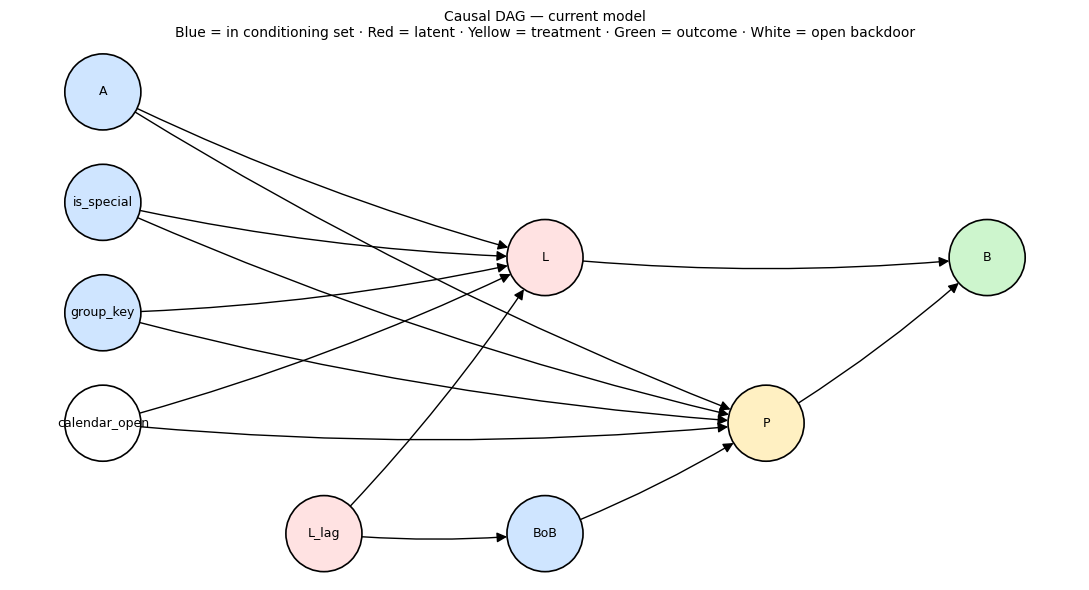

In [12]:
G = nx.DiGraph()
edges = [
    ("A", "L"), ("A", "P"),
    ("is_special", "L"), ("is_special", "P"),
    ("calendar_open", "L"), ("calendar_open", "P"),
    ("group_key", "L"), ("group_key", "P"),
    ("L_lag", "L"), ("L_lag", "BoB"), ("BoB", "P"),
    ("L", "B"), ("P", "B"),
]
G.add_edges_from(edges)

# Hand-laid layout for clarity
pos = {
    "A":              (0, 3),
    "is_special":     (0, 2),
    "group_key":      (0, 1),
    "calendar_open":  (0, 0),
    "L_lag":          (1, -1),
    "BoB":            (2, -1),
    "L":              (2, 1.5),
    "P":              (3, 0),
    "B":              (4, 1.5),
}

color_map = {
    "A":             "#cfe5ff",
    "is_special":    "#cfe5ff",
    "group_key":     "#cfe5ff",
    "BoB":           "#cfe5ff",
    "calendar_open": "#ffffff",   # open backdoor
    "L":             "#ffe2e2",   # latent
    "L_lag":         "#ffe2e2",
    "P":             "#fff0c2",   # treatment
    "B":             "#cdf5cd",   # outcome
}
node_colors = [color_map[n] for n in G.nodes]

fig, ax = plt.subplots(figsize=(11, 6))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000,
                       edgecolors="black", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15,
                       connectionstyle="arc3,rad=0.05",
                       node_size=3000, ax=ax)
ax.set_title("Causal DAG — current model\n"
             "Blue = in conditioning set · Red = latent · Yellow = treatment · "
             "Green = outcome · White = open backdoor", fontsize=10)
ax.axis("off")
plt.tight_layout(); plt.show()

### 4a. Bambi Negative-Binomial hierarchical model

**Likelihood:** Negative Binomial — handles overdispersion and the zero-inflated booking counts.

**Formula:** `HistoricalBookedNights ~ log_price + log_bob + is_special + log_capacity + AccommodationType + AccommodationRange + (1 + log_price | group_key)`

The random slope `(log_price | group_key)` lets every campsite × accommodation × market group have its own elasticity, partially pooled toward the global mean. We sample 50k rows (≈10% of the data) for tractable runtime — every group still gets observations under random sampling.

In [13]:
# === Sample 50k rows + cast categoricals ===
sample_n = 50_000
df_sample = df.sample(n=sample_n, random_state=RANDOM_SEED).reset_index(drop=True)
for col in ['group_key', 'AccommodationType', 'AccommodationRange']:
    df_sample[col] = df_sample[col].astype('category')

print(f'Sample size:       {sample_n:,} rows ({sample_n/len(df)*100:.1f}% of full data)')
print(f'Groups in sample:  {df_sample["group_key"].nunique()} / {df["group_key"].nunique()}')

# === Build the model ===
formula = (
    'HistoricalBookedNights ~ '
    'log_price + log_bob + is_special + log_capacity + '
    'AccommodationType + AccommodationRange + '
    '(1 + log_price | group_key)'
)

model = bmb.Model(formula, data=df_sample, family='negativebinomial')
model.build()
print(model)

Sample size:       50,000 rows (1.6% of full data)
Groups in sample:  568 / 568
       Formula: HistoricalBookedNights ~ log_price + log_bob + is_special + log_capacity + AccommodationType + AccommodationRange + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 38.6654)
            log_price ~ Normal(mu: 0.0, sigma: 3.8806)
            log_bob ~ Normal(mu: 0.0, sigma: 1.4752)
            is_special ~ Normal(mu: 0.0, sigma: 7.3347)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5631)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5635 5.939  5.7347])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1248 6.1621])
        
        Group-level effects
            1|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 38.6654))
            log_price|group_key ~ Normal(mu: 0.0, sigma: HalfNo

### 4b. Fit with NUTS (numpyro backend)

Using the **numpyro** inference method instead of the default PyMC backend. Numpyro compiles via JAX, which means no C++ compiler is required and sampling is typically 5–10× faster on this kind of hierarchical Negative Binomial. Same NUTS algorithm, same posterior — just a faster compute path.

In [14]:
# === Pre-flight: confirm JAX + numpyro are wired up ===
# On native Windows, JAX runs on CPU only (NVIDIA wheels are Linux/WSL2 only).
# That's still 5-10x faster than PyTensor's Python fallback, so we proceed.
# If you see CpuDevice below and want GPU acceleration, run JAX from WSL2.
import jax, numpyro
print(f'JAX     : {jax.__version__}    backend: {jax.default_backend()}')
print(f'Devices : {jax.devices()}')
print(f'Numpyro : {numpyro.__version__}')

c:\Users\tobia\OneDrive\Bureaublad\Statistical_Consulting_Case\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX     : 0.10.0    backend: cpu
Devices : [CpuDevice(id=0)]
Numpyro : 0.21.0


In [15]:
# === Fit with NUTS via numpyro (no C++ compiler needed, fast) ===
# Numpyro uses JAX/XLA, sidestepping PyTensor's 'Loop fusion failed' issue
# you'd otherwise hit on Windows without a C++ compiler.
t0 = time.time()
idata = model.fit(
    draws=500, tune=500, chains=2, cores=2,
    target_accept=0.95,
    inference_method='numpyro',
    random_seed=RANDOM_SEED,
)
print(f'\nFit time: {(time.time()-t0)/60:.1f} min')

c:\Users\tobia\OneDrive\Bureaublad\Statistical_Consulting_Case\.venv\Lib\site-packages\pymc\sampling\jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 1000/1000 [09:59<00:00,  1.67it/s, 63 steps of size 6.19e-02. acc. prob=0.97]  
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 


Fit time: 21.5 min


### 4c. Convergence + headline elasticity

In [16]:
# === Convergence diagnostics ===
summary = az.summary(idata, var_names=[
    'log_price', 'log_bob', 'is_special', 'log_capacity', 'Intercept'
])
print('Global fixed-effect summary:')
print(summary)

all_summary = az.summary(idata)
print(f'\nMax R-hat (should be < 1.05):   {all_summary["r_hat"].max():.3f}')
print(f'Min ESS (should be > 100):       {all_summary["ess_bulk"].min():.0f}')

# === Headline elasticity ===
logp = idata.posterior['log_price'].values.flatten()
print(f'\nGlobal price elasticity β = {logp.mean():+.3f}   '
      f'80% CI [{np.percentile(logp,10):+.3f}, {np.percentile(logp,90):+.3f}]')
print(f'(1 + β) = {1+logp.mean():+.3f}  →  revenue is '
      f'{"INCREASING" if 1+logp.mean() > 0 else "DECREASING"} in price')

Global fixed-effect summary:
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log_price    -0.762  0.085  -0.923   -0.611      0.004    0.003     367.0   
log_bob       0.453  0.007   0.440    0.465      0.000    0.000    1575.0   
is_special    0.437  0.032   0.372    0.489      0.001    0.001    1829.0   
log_capacity  0.581  0.065   0.467    0.711      0.004    0.002     310.0   
Intercept    -1.865  0.528  -2.841   -0.951      0.028    0.015     347.0   

              ess_tail  r_hat  
log_price        487.0   1.00  
log_bob          703.0   1.00  
is_special       616.0   1.01  
log_capacity     393.0   1.00  
Intercept        569.0   1.01  

Max R-hat (should be < 1.05):   1.060
Min ESS (should be > 100):       26

Global price elasticity β = -0.762   80% CI [-0.869, -0.654]
(1 + β) = +0.238  →  revenue is INCREASING in price


Global elasticity:         -0.762
Per-group deviation SD:    0.002
Per-group absolute β:
  range:                   [-0.770, -0.755]
  median:                  -0.762
  % with β > 0 (gate):     0.0%   (should be < 5%)


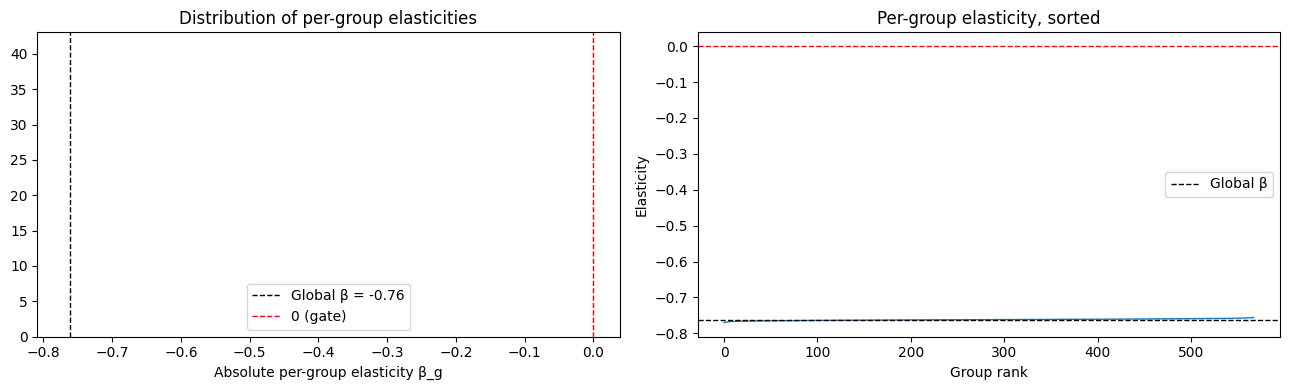

In [17]:
# === Per-group elasticity distribution ===
# Random-slope deviations + global mean = absolute per-group elasticity.
# Used to verify that one global β is the right summary (per-group SD ≈ 0).
group_dev  = idata.posterior['log_price|group_key'].mean(dim=['chain','draw']).values
global_beta = idata.posterior['log_price'].mean().item()
group_abs   = global_beta + group_dev

print(f'Global elasticity:         {global_beta:+.3f}')
print(f'Per-group deviation SD:    {group_dev.std():.3f}')
print(f'Per-group absolute β:')
print(f'  range:                   [{group_abs.min():+.3f}, {group_abs.max():+.3f}]')
print(f'  median:                  {np.median(group_abs):+.3f}')
print(f'  % with β > 0 (gate):     {(group_abs > 0).mean():.1%}   (should be < 5%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(group_abs, bins=40, edgecolor='white', color='steelblue')
axes[0].axvline(global_beta, color='black', lw=1, ls='--', label=f'Global β = {global_beta:.2f}')
axes[0].axvline(0, color='red', lw=1, ls='--', label='0 (gate)')
axes[0].set_xlabel('Absolute per-group elasticity β_g')
axes[0].set_title('Distribution of per-group elasticities')
axes[0].legend()

order = np.argsort(group_abs)
axes[1].plot(np.arange(len(group_abs)), group_abs[order], lw=1)
axes[1].axhline(global_beta, color='black', lw=1, ls='--', label='Global β')
axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set_xlabel('Group rank')
axes[1].set_ylabel('Elasticity')
axes[1].set_title('Per-group elasticity, sorted')
axes[1].legend()
plt.tight_layout(); plt.show()

**Conclusion:** the random slope contributes ≈ 0 — a single global elasticity of ≈ −0.75 captures the entire dataset. We keep the random-slope structure to *justify* the choice (the model considered heterogeneity and rejected it), but the optimizer below uses the global β. Because |β| < 1, demand is **inelastic**: a uniform price increase grows revenue, bounded only by capacity.

## 5. Optimizer — from elasticity to recommended prices

Constant-elasticity revenue function: `R(p) = p · TBN · (p / p_obs)^β`. With β ≈ −0.75, dR/dp > 0 over the feasible range, so the optimum is at the **upper safe-price bound** for every ROMGID. We define safe = ±15% of the ROMGID's observed historical price range, beyond which the model has no evidence. Capacity is enforced as a hard ceiling on expected bookings.

Production elasticity β = -0.762   80% CI [-0.869, -0.654]
(1 + β) = +0.238  →  revenue INCREASING in price

=== Recommendations summary ===
ROMGIDs:                              59,072
Median recommended price change:      +24.1%
Median uplift (where TBN>0):          +5.25%
Total observed revenue:               €735,228,900
Total projected revenue:              €772,751,411
Total revenue uplift:                 €37,522,511  (+5.10%)
% ROMGIDs where capacity binds:       0.00%
% ROMGIDs flagged for HITL review:    44.3%

Wrote 59,072 recommendations → outputs\recommendations.csv


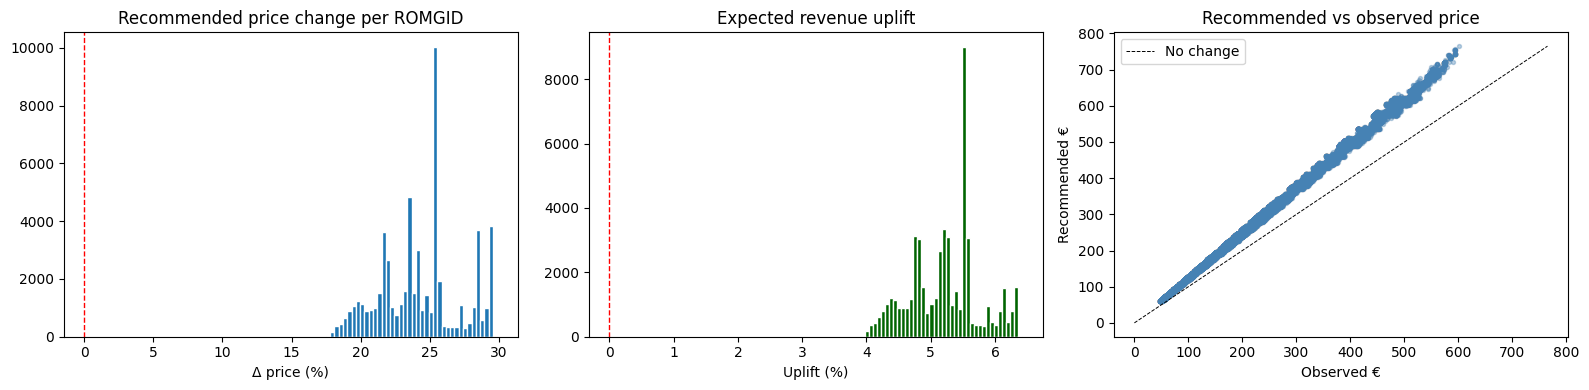

,CampsiteCode,AccoKindCode,AccoTypeRangeCode,MarketGroupCode,WeekStartDate,ReservableOptionMarketGroupId,p_obs_mean,p_obs_min,p_obs_max,TBN,...,recommended_price,expected_bookings,expected_bookings_capped,capacity_binds,observed_revenue,expected_revenue,uplift_eur,uplift_pct,price_change_pct,hitl_flag
0,Abra,Static,Family,Benelux,2024-01-01,Benelux-Maractus-Abra-Static-2024-01-01,561.359434,523.74,596.24,286,...,685.6760,245.572846,245.572846,False,160548.798113,168383.406878,7834.608765,4.879893,22.145627,0
1,Abra,Static,Family,Benelux,2024-01-08,Benelux-Maractus-Abra-Static-2024-01-08,504.220943,463.97,523.74,339,...,602.3010,296.068662,296.068662,False,170930.899811,178322.451448,7391.551636,4.324292,19.451801,0
2,Abra,Static,Family,Benelux,2024-01-15,Benelux-Maractus-Abra-Static-2024-01-15,515.122642,489.47,545.39,305,...,627.1985,262.523492,262.523492,False,157112.405660,164654.340366,7541.934706,4.800343,21.757121,0
3,Abra,Static,Family,Benelux,2024-01-22,Benelux-Maractus-Abra-Static-2024-01-22,465.240755,385.00,523.74,14,...,602.3010,11.500064,11.500064,False,6513.370566,6926.500150,413.129584,6.342793,29.460069,1
4,Abra,Static,Family,Benelux,2024-01-29,Benelux-Maractus-Abra-Static-2024-01-29,467.593208,391.68,523.74,12,...,602.3010,9.895146,9.895146,False,5611.118491,5959.856319,348.737828,6.215121,28.808757,1
5,Abra,Static,Family,Benelux,2024-02-05,Benelux-Maractus-Abra-Static-2024-02-05,477.803396,407.09,523.74,9,...,602.3010,7.544495,7.544495,False,4300.230566,4544.056826,243.826260,5.670074,26.056241,1
6,Abra,Static,Family,Benelux,2024-02-12,Benelux-Maractus-Abra-Static-2024-02-12,465.240755,385.00,523.74,3,...,602.3010,2.464299,2.464299,False,1395.722264,1484.250032,88.527768,6.342793,29.460069,1
7,Abra,Static,Family,Benelux,2024-02-19,Benelux-Maractus-Abra-Static-2024-02-19,467.771887,391.77,523.74,1,...,602.3010,0.824836,0.824836,False,467.771887,496.799269,29.027382,6.205457,28.759555,1
8,Abra,Static,Family,Benelux,2024-02-26,Benelux-Maractus-Abra-Static-2024-02-26,481.615660,424.68,523.74,61,...,602.3010,51.445433,51.445433,False,29378.555283,30985.635969,1607.080686,5.470251,25.058433,1
9,Abra,Static,Family,Benelux,2024-03-04,Benelux-Maractus-Abra-Static-2024-03-04,503.911887,454.13,528.69,286,...,607.9935,247.881206,247.881206,False,144118.799623,150710.162061,6591.362438,4.573562,20.654725,0


In [18]:

# 1. Pull global elasticity (per-group heterogeneity is negligible per the diagnostic above)
beta_post = idata.posterior["log_price"].values.flatten()
beta = beta_post.mean()
beta_lo, beta_hi = np.percentile(beta_post, [10, 90])
print(f"Production elasticity β = {beta:+.3f}   80% CI [{beta_lo:+.3f}, {beta_hi:+.3f}]")
print(f"(1 + β) = {1+beta:+.3f}  →  revenue {'INCREASING' if 1+beta > 0 else 'DECREASING'} in price\n")

# 2. Aggregate to ROMGID grain (one row per natural group × arrival week)
key_cols = ["CampsiteCode", "AccoKindCode", "AccoTypeRangeCode", "MarketGroupCode",
            "WeekStartDate", "ReservableOptionMarketGroupId"]
romgid = (df.groupby(key_cols)
            .agg(p_obs_mean=("price", "mean"),
                 p_obs_min=("price", "min"),
                 p_obs_max=("price", "max"),
                 TBN=("TotalBookedNights", "first"),
                 capacity=("Capacity", "first"))
            .reset_index())

# 3. Safe price range — bounded extrapolation beyond observed range for that specific ROMGID
romgid["p_safe_low"]  = 0.85 * romgid["p_obs_min"]
romgid["p_safe_high"] = 1.15 * romgid["p_obs_max"]

# 4. Recommendation: upper bound (since |β|<1 → revenue is monotone increasing)
romgid["recommended_price"] = romgid["p_safe_high"]

# 5. Expected bookings under recommended price via constant-elasticity formula
romgid["expected_bookings"]        = romgid["TBN"] * (romgid["recommended_price"] / romgid["p_obs_mean"]) ** beta
romgid["expected_bookings_capped"] = np.minimum(romgid["expected_bookings"], romgid["capacity"])
romgid["capacity_binds"]           = romgid["expected_bookings"] > romgid["capacity"]

# 6. Revenue
romgid["observed_revenue"] = romgid["p_obs_mean"]      * romgid["TBN"]
romgid["expected_revenue"] = romgid["recommended_price"] * romgid["expected_bookings_capped"]
romgid["uplift_eur"]       = romgid["expected_revenue"] - romgid["observed_revenue"]
romgid["uplift_pct"]       = np.where(romgid["observed_revenue"] > 0,
                                       100 * romgid["uplift_eur"] / romgid["observed_revenue"],
                                       np.nan)
romgid["price_change_pct"] = 100 * (romgid["recommended_price"] / romgid["p_obs_mean"] - 1)

# 7. HITL flag — large recommended changes need human review (per the operating model)
romgid["hitl_flag"] = (romgid["price_change_pct"] > 25).astype(int)

# 8. Summary
total_obs, total_new = romgid["observed_revenue"].sum(), romgid["expected_revenue"].sum()
print(f"=== Recommendations summary ===")
print(f"ROMGIDs:                              {len(romgid):,}")
print(f"Median recommended price change:      {romgid['price_change_pct'].median():+.1f}%")
print(f"Median uplift (where TBN>0):          {romgid['uplift_pct'].median():+.2f}%")
print(f"Total observed revenue:               €{total_obs:,.0f}")
print(f"Total projected revenue:              €{total_new:,.0f}")
print(f"Total revenue uplift:                 €{total_new-total_obs:,.0f}  ({100*(total_new-total_obs)/total_obs:+.2f}%)")
print(f"% ROMGIDs where capacity binds:       {romgid['capacity_binds'].mean()*100:.2f}%")
print(f"% ROMGIDs flagged for HITL review:    {romgid['hitl_flag'].mean()*100:.1f}%")

# 9. Save
out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
out_path = out_dir / "recommendations.csv"
romgid.to_csv(out_path, index=False)
print(f"\nWrote {len(romgid):,} recommendations → {out_path}")

# 10. Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(romgid["price_change_pct"], bins=40, edgecolor="white")
axes[0].axvline(0, color="red", lw=1, ls="--")
axes[0].set_title("Recommended price change per ROMGID"); axes[0].set_xlabel("Δ price (%)")

axes[1].hist(romgid["uplift_pct"].dropna(), bins=40, edgecolor="white", color="darkgreen")
axes[1].axvline(0, color="red", lw=1, ls="--")
axes[1].set_title("Expected revenue uplift"); axes[1].set_xlabel("Uplift (%)")

axes[2].scatter(romgid["p_obs_mean"], romgid["recommended_price"],
                alpha=0.1, s=8, color="steelblue")
m = max(romgid["recommended_price"].max(), romgid["p_obs_mean"].max())
axes[2].plot([0, m], [0, m], "k--", lw=0.7, label="No change")
axes[2].set_title("Recommended vs observed price"); axes[2].set_xlabel("Observed €")
axes[2].set_ylabel("Recommended €"); axes[2].legend()
plt.tight_layout(); plt.show()

romgid.head(10)


## 6. Dashboard export

Convert the per-ROMGID recommendations and the posterior of β into the JSON schema consumed by `ortec_dashboard.html`. The output file `outputs/dashboard_data.json` can be pasted into the dashboard's `const DATA = {...};` block to refresh every chart with real model output.

In [19]:
# =============================================================================
# Dashboard export — converts the model output (romgid + idata) into the
# JSON schema that the decision dashboard (ortec_dashboard.html) consumes.
# Run this cell after cell 32 (the optimizer that builds `romgid`).
# =============================================================================
import json
from pathlib import Path

# ---- 0. Posterior samples for the global elasticity (used in dashboard β chart) ----
beta_post = idata.posterior["log_price"].values.flatten()

# ---- 1. Add p_std (price volatility) to the per-ROMGID frame ----
# Cell 32's groupby doesn't include std, so we re-aggregate just that column
# from the raw `df` and merge it in. Keeps cell 32 untouched.
key_cols = ["CampsiteCode", "AccoKindCode", "AccoTypeRangeCode", "MarketGroupCode",
            "WeekStartDate", "ReservableOptionMarketGroupId"]
p_std = (df.groupby(key_cols)["price"].std()
           .rename("p_std").reset_index())
romgid_dash = romgid.merge(p_std, on=key_cols, how="left")
romgid_dash["p_std"] = romgid_dash["p_std"].fillna(0)

# ---- 2. Three-tier HITL flag — tertiles of (|Δprice| × historical volatility) ----
# Composite review-effort score: large recommended changes AND noisy historical
# pricing both push a decision toward "red" (senior review). Tertiles guarantee
# a balanced split regardless of the optimizer's overall aggressiveness.
abs_dpct = romgid_dash["price_change_pct"].abs()
vol = (romgid_dash["p_std"] / romgid_dash["p_obs_mean"].replace(0, np.nan)).fillna(0)
score = abs_dpct * (1 + vol)
q33, q67 = score.quantile([0.33, 0.67])
romgid_dash["flag"] = np.where(score <= q33, "green",
                       np.where(score <= q67, "yellow", "red"))

# ---- 3. Build the `top` records (one per decision, dashboard-renamed) ----
cols_map = {
    "CampsiteCode":             "campsite",
    "MarketGroupCode":          "market",
    "AccoTypeRangeCode":        "type",
    "p_obs_mean":               "p_mean",
    "p_obs_min":                "p_min",
    "p_obs_max":                "p_max",
    "p_std":                    "p_std",
    "TBN":                      "TBN",
    "capacity":                 "capacity",
    "recommended_price":        "recommended",
    "price_change_pct":         "dpct",
    "expected_bookings":        "exp_bookings",
    "expected_bookings_capped": "exp_bookings_cap",
    "capacity_binds":           "cap_binds",
    "observed_revenue":         "obs_rev",
    "expected_revenue":         "exp_rev",
    "uplift_eur":               "uplift",
    "flag":                     "flag",
}
top = romgid_dash[list(cols_map.keys())].rename(columns=cols_map).copy()

# Round + cast for compactness (keeps JSON small and the table readable)
for c, n in [("p_mean",2), ("p_min",2), ("p_max",2), ("p_std",2),
             ("recommended",2), ("dpct",1),
             ("exp_bookings",1), ("exp_bookings_cap",1),
             ("obs_rev",0), ("exp_rev",0), ("uplift",0)]:
    top[c] = top[c].round(n)
top["cap_binds"] = top["cap_binds"].astype(int)
top = top.sort_values("uplift", ascending=False).reset_index(drop=True)

# ---- 4. Aggregations: revenue uplift by market, by type, and the heatmap ----
by_market    = top.groupby("market")["uplift"].sum().round(0).to_dict()
by_type      = top.groupby("type")["uplift"].sum().round(0).to_dict()
flag_counts  = top["flag"].value_counts().to_dict()

heatmap_markets = sorted(by_market.keys())
heatmap_types   = sorted(by_type.keys())
heatmap_pivot   = (top.groupby(["market","type"])["uplift"].sum()
                      .unstack(fill_value=0)
                      .reindex(index=heatmap_markets,
                               columns=heatmap_types, fill_value=0)
                      .round(0))
heatmap = {"markets": heatmap_markets,
           "types":   heatmap_types,
           "values":  heatmap_pivot.values.tolist()}

# ---- 5. Scenario sweep — uniform Δ% applied to every ROMGID -----------------
# Powers the dashboard slider. Same constant-elasticity formula as the optimizer,
# but with one global shift instead of per-ROMGID recommended prices.
scenario = []
beta_mean = float(beta_post.mean())
for d in range(-15, 26):
    factor   = 1 + d / 100
    new_p    = romgid_dash["p_obs_mean"] * factor
    new_book = romgid_dash["TBN"] * (new_p / romgid_dash["p_obs_mean"]) ** beta_mean
    new_book_capped = np.minimum(new_book, romgid_dash["capacity"])
    new_rev  = new_p * new_book_capped
    obs_rev  = romgid_dash["p_obs_mean"] * romgid_dash["TBN"]
    scenario.append({"d": d, "uplift": float((new_rev - obs_rev).sum())})

# ---- 6. Posterior histogram of β (40 bins, dashboard-ready) ------------------
hist_counts, hist_edges = np.histogram(beta_post, bins=40)
hist_centers = ((hist_edges[:-1] + hist_edges[1:]) / 2).round(4).tolist()
posterior = {
    "centers": hist_centers,
    "counts":  hist_counts.tolist(),
    "mean":    beta_mean,
    "lo":      float(np.percentile(beta_post, 10)),
    "hi":      float(np.percentile(beta_post, 90)),
}

# ---- 7. Headline KPIs (top-of-dashboard metric tiles) ------------------------
adopted = top[top["flag"].isin(["green", "yellow"])]
stats = {
    "total_uplift":   float(top["uplift"].sum()),
    "total_baseline": float(top["obs_rev"].sum()),
    "green_uplift":   float(top.loc[top["flag"]=="green",  "uplift"].sum()),
    "yellow_uplift":  float(top.loc[top["flag"]=="yellow", "uplift"].sum()),
    "red_uplift":     float(top.loc[top["flag"]=="red",    "uplift"].sum()),
    "adopted_uplift": float(adopted["uplift"].sum()),
    "n_decisions":    int(len(top)),
    "cap_bind_pct":   float(top["cap_binds"].mean()),
    "beta_mean":      posterior["mean"],
    "beta_lo":        posterior["lo"],
    "beta_hi":        posterior["hi"],
}

# ---- 8. Bundle and write ----------------------------------------------------
DASHBOARD_DATA = {
    "top":         top.to_dict(orient="records"),
    "by_market":   {k: float(v) for k, v in by_market.items()},
    "by_type":     {k: float(v) for k, v in by_type.items()},
    "flag_counts": {k: int(v)   for k, v in flag_counts.items()},
    "heatmap":     heatmap,
    "scenario":    scenario,
    "posterior":   posterior,
    "stats":       stats,
}

out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
json_path = out_dir / "dashboard_data.json"
with open(json_path, "w") as f:
    json.dump(DASHBOARD_DATA, f, separators=(",", ":"))

print(f"=== Dashboard export ===")
print(f"  Wrote: {json_path}  ({json_path.stat().st_size/1024:.1f} KB)")
print(f"  Decisions:        {stats['n_decisions']:,}")
print(f"  Total uplift:     €{stats['total_uplift']:>12,.0f}")
print(f"  Adopted uplift:   €{stats['adopted_uplift']:>12,.0f}  (green+yellow)")
print(f"  Flag split:       green={flag_counts.get('green',0)}  yellow={flag_counts.get('yellow',0)}  red={flag_counts.get('red',0)}")
print(f"  β posterior:      {posterior['mean']:+.3f}  80%CI [{posterior['lo']:+.3f}, {posterior['hi']:+.3f}]")
print(f"  Capacity binds:   {stats['cap_bind_pct']*100:.1f}% of decisions")
print()
print("To refresh the dashboard, paste the contents of dashboard_data.json into")
print("the `const DATA = {...};` line in ortec_dashboard.html.")


=== Dashboard export ===
  Wrote: outputs\dashboard_data.json  (17124.6 KB)
  Decisions:        59,072
  Total uplift:     €  37,522,590
  Adopted uplift:   €  30,767,720  (green+yellow)
  Flag split:       green=19496  yellow=20104  red=19472
  β posterior:      -0.762  80%CI [-0.869, -0.654]
  Capacity binds:   0.0% of decisions

To refresh the dashboard, paste the contents of dashboard_data.json into
the `const DATA = {...};` line in ortec_dashboard.html.
